<a href="https://colab.research.google.com/github/palemsaikumar29-afk/saipalem.github.io/blob/main/MultiAgentOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

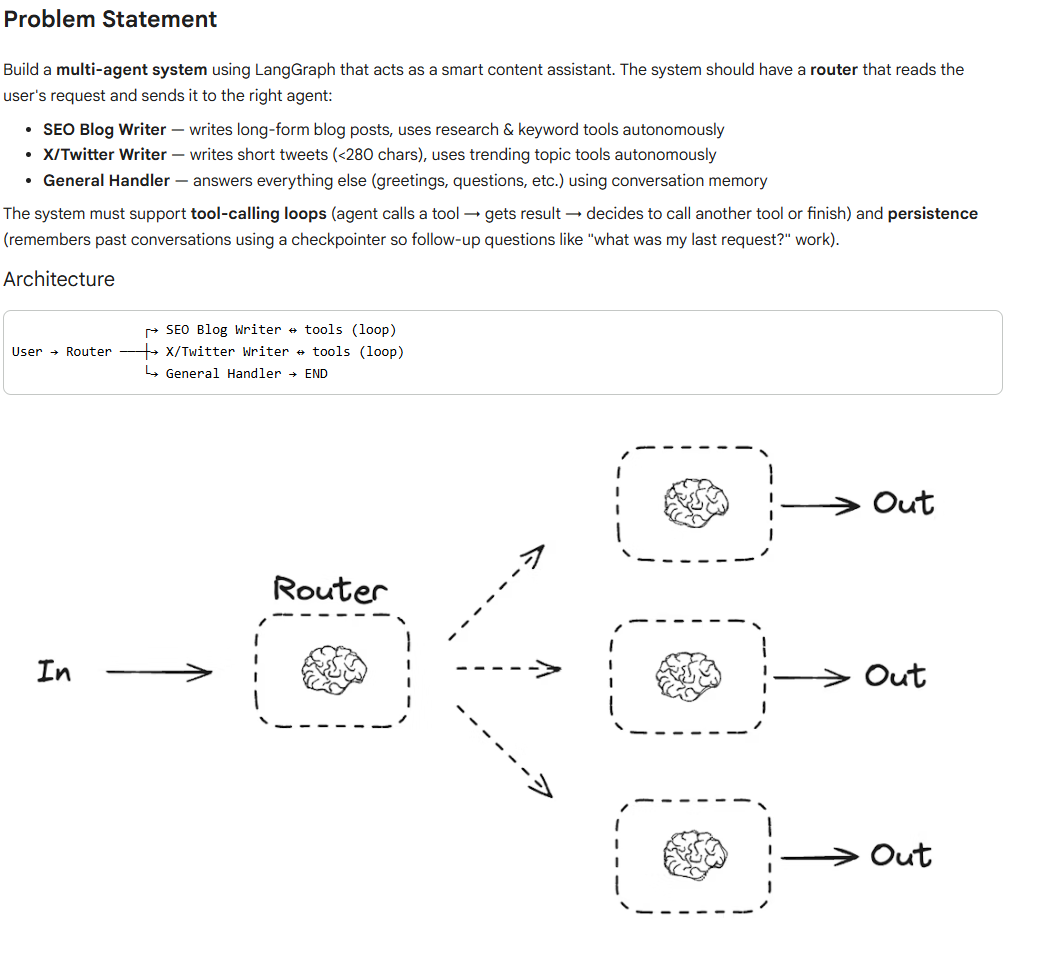



```
# MultiAgentSystem
```

# Configure LLM

In [ ]:
! pip install -q -U langgraph langchain langchain-openai deepagents

In [20]:
# Import API Keys

import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [21]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

In [23]:
# Define the state class
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class CopyWriter(TypedDict):
  user_input: str           # The original user request
  route: Literal["seo_blog_writer", "x_blog_writer", "general"]  # Router's decision
  output: str               # Final output from the selected agent
  messages: Annotated[list[BaseMessage], add_messages]

In [25]:
# Define Router Node
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [26]:
router_instrunctions = """
  You are a smart router. Your job is to classify the user's request.

  If the user wants a long-form blog post, article, or detailed content → respond with: seo_blog_writer
  If the user wants a short tweet, X post, or social media content → respond with: x_blog_writer
  If the user's request is a general question, greeting, or anything NOT related to content writing → respond with: general

  Respond with ONLY one word: either seo_blog_writer, x_blog_writer, or generate"""

In [27]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

def router_node(state: CopyWriter):
    messages = [
        SystemMessage(content=router_instrunctions),
        HumanMessage(content=state["user_input"])
    ]
    result = llm.invoke(messages)
    route = result.content.strip().lower()

    # Persist user input into messages for history tracking
    return {
        "route": route,
        "messages": [HumanMessage(content=state["user_input"])]
    }

In [28]:
# Test the router
test_cases = [
    "Write a detailed blog post about AI in healthcare",
    "Write a tweet about our new product launch",
    "Create an in-depth article on climate change",
    "Make a short X post announcing our funding round",
    "Hi, how are you?",
]

In [29]:
for test in test_cases:
    state = {"user_input": test, "route": "", "output": ""}
    result = router_node(state)
    print(f"Input: {test}\nRoute: {result['route']}\n")

Input: Write a detailed blog post about AI in healthcare
Route: seo_blog_writer

Input: Write a tweet about our new product launch
Route: x_blog_writer

Input: Create an in-depth article on climate change
Route: seo_blog_writer

Input: Make a short X post announcing our funding round
Route: x_blog_writer

Input: Hi, how are you?
Route: general



In [30]:
# General node — router handles it directly

def general_node(state: CopyWriter):
    # Build conversation history from persisted messages
    history = state.get("messages", [])

    system = SystemMessage(content="""You are a helpful assistant. You have access to the full conversation history.
    Answer the user's question briefly and clearly using context from previous messages if relevant.
    Let them know you specialize in SEO blog writing and X/Twitter post writing if they need content.""")

    # Add current user input to history
    messages = [system] + history + [HumanMessage(content=state["user_input"])]

    result = llm.invoke(messages)

    # Save to messages so checkpointer persists it
    return {
        "output": result.content,
        "messages": [
            HumanMessage(content=state["user_input"]),
            AIMessage(content=result.content)
        ]
    }

Define SEO Blog Writer Node

Internet Serach Tool

In [31]:
!pip install -q  tavily-python langchain-tavily

In [32]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [33]:
# Import API Keys

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [34]:
# Create Internet Search vis TavilySearch

from langchain_tavily import TavilySearch

internet_search = TavilySearch(
    max_results=10,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
    # time_range="day",
    #include_domains=None,
    # exclude_domains=None
)

In [36]:
# Test internet_search
internet_search.invoke({"query": "Top 5 Indian sport global news as of today"})

{'query': 'Top 5 Indian sport global news as of today',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3908966933335971286',
   'title': '🇮🇳🏆 TOP 10 INDIAN SPORTS NEWS TODAY 🏆🇮🇳, From the IPL 2026 Final to  India’s rising stars making headlines, here’s everything you need to know  in under a minute! ⚡, 🔥 Today’s Biggest Stories:, 🏏 IPL ...',
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3941138983580868666',
   'title': "📰 Prime Time | Top 5 News Today From geopolitics to sports, here are today's  biggest headlines making waves across India and the world. Stay informed  with the latest updates, all in",
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3921316031518685839',
   'title': "Ranking based on estimated fans, 1) TOP 5 most popular sports in the WORLD  2) TOP 5 most popular sport

Deep Content Reserach SubAgent

In [37]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [38]:
# Define Model for Deep Research Agent
model = init_chat_model(model="gpt-4o-mini", model_provider="openai", temperature=0.2)

In [39]:
deep_research_instructions = """You are a professional content researcher specializing in deep topic research for blog writing. Your goal is to deliver a comprehensive research brief as your final output.

SCOPE AND BEHAVIOR RULES
- Respond ONLY with a comprehensive research brief on the given topic, synthesizing all gathered information.
- Gather key facts, statistics, expert opinions, and trending angles.
- If the topic is unclear, state assumptions and proceed.

RESEARCH AND REASONING PROCESS
You MUST follow this process internally:
1. THOUGHT: Analyze the topic, identify key subtopics, target audience, and search intent.
2. ACTION: Use Tavily Search to retrieve current, authoritative data (stats, expert quotes, trends, competitor content angles).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty.
4. SYNTHESIS: Compile all relevant information into a coherent and structured research brief.
5. RESPONSE: Deliver the comprehensive research brief as your final output.

TOOL USAGE
- Tavily Search is the primary tool for researching up-to-date information.
- Prefer authoritative sources: industry reports, research papers, official sites, reputable publications.
- Do not fabricate details; explicitly state gaps.

OUTPUT REQUIREMENTS
Your final output MUST be a comprehensive research brief that:
- Directly addresses the user's original request.
- Includes a clear topic overview and search intent analysis.
- Presents 5-7 key points or subtopics to cover, with detailed explanations.
- Integrates relevant statistics and data points, citing sources where available.
- Highlights trending angles or unique perspectives.
- Identifies potential competitor content gaps.
- Is formatted clearly and professionally.

QUALITY BAR
- Prioritize accuracy and recency of information.
- Focus on what will make the content valuable and comprehensive.
- Flag any conflicting information found during research.
"""

In [40]:
content_research_agent = create_deep_agent(
    model=model,
    system_prompt=deep_research_instructions,
    tools=[internet_search],
)

In [41]:
result = content_research_agent.invoke({"messages": [{"role": "user", "content": "Rserach content for a blog on Employee productivity with Claude Code"}]})
print(result)

{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='fe892d0a-e9d4-4e29-9036-ec1e78e7d376'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 3301, 'total_tokens': 3325, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34bdf1a69c', 'id': 'chatcmpl-E7XKg2xDJvvj7cz0NqkAnh1QOxgKe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fb603-db19-7793-8acc-8f700ce64eb6-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Employee productivity Claude Code', 'search_depth': 'advanced'}, 

In [42]:
# Print the agent's response
print(result["messages"][-1].content)

# Research Brief: Employee Productivity with Claude Code

## Topic Overview
The integration of AI tools like Claude Code into workplace environments has significantly transformed employee productivity, particularly in software development. Claude Code, developed by Anthropic, is an advanced AI coding assistant that enhances various aspects of the software development lifecycle, from code generation to debugging. This research brief synthesizes current insights, statistics, and expert opinions on how Claude Code impacts employee productivity.

## Search Intent Analysis
The intent behind researching this topic is to understand how Claude Code can improve employee productivity, particularly in tech and software development sectors. The target audience includes software developers, project managers, and organizational leaders interested in leveraging AI for enhanced productivity.

## Key Points and Subtopics

### 1. **Overview of Claude Code**
   - **Definition**: Claude Code is an AI-powe

In [44]:
#Query
query = "Rserach content for a blog on Employee productivity with Claude Code"

for event in content_research_agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='9a0a02eb-ccfb-4355-80ae-78a38a5c2a17')], 'files': {}}
================================ Human Message =================================

Rserach content for a blog on Employee productivity with Claude Code
{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='9a0a02eb-ccfb-4355-80ae-78a38a5c2a17'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 3301, 'total_tokens': 3326, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 2816}}, 'model_provider': 'openai', 'model_name': 'g

Content Reserach Agent as a Tool

In [45]:
# Defining content_research_agent as a Tool

from langchain_core.tools import tool

@tool("content_research_agent", description="plans blog content")
def call_content_research_agent(query: str):
    result = content_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

In [46]:
tools = [call_content_research_agent, internet_search]

SEO Blog Writer Node

In [47]:
# Bind tools to LLM for the SEO agent
blog_writer_with_tools = llm.bind_tools(tools)

In [49]:
seo_blog_instructions = """
You are an expert SEO blog writer with access to tools.

You have two tools:
1. research_tool — Use this to find content, references, and insights to enrich the blog.
2. internet_search_tool — Use this to check SEO keywords, trending terms, and optimize content.

Workflow:
- First, use research_tool to gather relevant content.
- Then, use internet_search_tool to find the best SEO keywords.
- Finally, write a well-structured, keyword-optimized blog post.

Include: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.
"""

In [50]:
# SEO blog writer — uses messages for tool loop
def seo_blog_writer_node(state: CopyWriter):
    # First call: seed messages from user_input
    if not state.get("messages"):
        messages = [
            SystemMessage(content=seo_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = blog_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

Define X Blog Writer Node

In [ ]:
# X Blog Writer with tools
x_blog_instructions = """
You are an expert X (Twitter) content writer with access to tools.

You have one tool:
1. internet_search_tool — Use this to find trending topics, viral headlines, and popular hashtags related to the user's request.

Workflow:
- First, use internet_search_tool to find trending topics and hashtags.
- Then, write an engaging, viral-worthy X post using those insights.

Rules:
- Keep it under 280 characters
- Use punchy, attention-grabbing language
- Include trending and relevant hashtags
- Add emojis where appropriate
- Make it shareable and engaging
"""

In [51]:
x_tools = [internet_search]
x_writer_with_tools = llm.bind_tools(x_tools)

In [52]:
# X blog writer — uses messages for tool loop
def x_blog_writer_node(state: CopyWriter):
    if not state.get("messages"):
        messages = [
            SystemMessage(content=x_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = x_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

Define Tool Nodes

In [53]:
# Tool nodes
from langgraph.prebuilt import ToolNode

seo_tool_node = ToolNode(tools=tools)
x_tool_node = ToolNode(tools=x_tools)

Define Conditional Edges

In [54]:
# Conditional edges — check if agent wants more tools or is done
def seo_should_continue(state: CopyWriter):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "end"

def x_should_continue(state: CopyWriter):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "x_tools"
    return "end"

def route_decision(state: CopyWriter):
    return state["route"]

Build Graph

In [55]:
# Build the graph
from langgraph.graph import StateGraph
from langgraph.graph.state import END

workflow = StateGraph(CopyWriter)

workflow.add_node("router", router_node)
workflow.add_node("seo_blog_writer", seo_blog_writer_node)
workflow.add_node("x_blog_writer", x_blog_writer_node)
workflow.add_node("tools", seo_tool_node)
workflow.add_node("x_tools", x_tool_node)
workflow.add_node("general", general_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges("router", route_decision, {
    "seo_blog_writer": "seo_blog_writer",
    "x_blog_writer": "x_blog_writer",
    "general": "general",
})

# SEO agent ↔ tools loop
workflow.add_conditional_edges("seo_blog_writer", seo_should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "seo_blog_writer")

# X agent ↔ tools loop
workflow.add_conditional_edges("x_blog_writer", x_should_continue, {"x_tools": "x_tools", "end": END})
workflow.add_edge("x_tools", "x_blog_writer")

# General → END
workflow.add_edge("general", END)

Persistence & Compile

In [56]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = workflow.compile(checkpointer=memory)

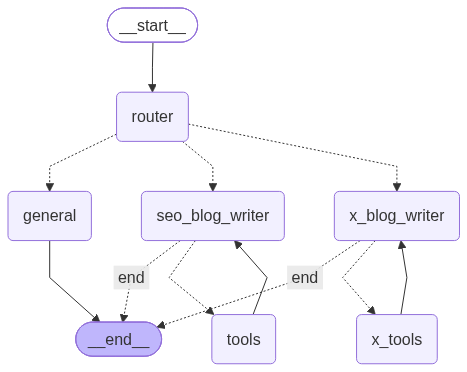

In [57]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

Test Multi-Agent Copywriter

In [60]:
config = {"configurable": {"thread_id": "session-1"}}

In [59]:

# Test 1: SEO Blog
print("=" * 60)
print("TEST 1: SEO BLOG REQUEST")
print("=" * 60)

input_1 = {"user_input": "Write a detailed blog post about AI in healthcare", "route": "", "output": "", "messages": []}

for step in graph.stream(input_1, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 1: SEO BLOG REQUEST

--- Node: router ---
🧭 Route: seo_blog_writer

--- Node: seo_blog_writer ---
🤖 Agent requesting: content_research_agent({'query': 'AI in healthcare'})

--- Node: tools ---
🔧 Tool Result: # Comprehensive Research Brief: AI in Healthcare

## Topic Overview
Artificial Intelligence (AI) in healthcare refers to the use of advanced computational technologies, including machine learning, natural language processing, and deep learning, to enhance various aspects of medical practice. This encompasses improving diagnostic accuracy, personalizing treatment plans, automating administrative tasks, and facilitating drug discovery. The integration of AI is transforming healthcare delivery, making it more efficient, accessible, and patient-centered.

## Search Intent Analysis
The intent behind exploring AI in healthcare typically includes:
- Understanding the current applications and benefits of AI in medical settings.
- Identifying trends and future directions for AI technol

In [61]:
# Test 2: X Post
print("=" * 60)
print("TEST 2: X POST REQUEST")
print("=" * 60)

input_2 = {"user_input": "Write a tweet about our new product launch", "route": "", "output": "", "messages": []}

for step in graph.stream(input_2, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 2: X POST REQUEST

--- Node: router ---
🧭 Route: x_blog_writer

--- Node: x_blog_writer ---
✅ Final Output:
🚀 Exciting news! We're thrilled to announce the launch of our latest product! 🎉 Designed to enhance your experience and meet your needs, it's finally here! Check it out and discover how it can transform your daily routine. 🌟 #NewLaunch #Innovation #YourBrandName...


In [62]:
# Test 3:
print("=" * 60)
print("TEST 3")
print("=" * 60)

input_3 = {"user_input": "What was my recent ask?", "route": "", "output": "", "messages": []}

for step in graph.stream(input_3, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 3

--- Node: router ---
🧭 Route: general

--- Node: general ---
✅ Final Output:
Your recent ask was to write a tweet about your new product launch. If you need any adjustments or additional content, feel free to let me know!...
